här importeras bibliotek 

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans

här läser vi in dataset

In [10]:
df = pd.read_csv("housing.csv")

tre kolumner väljs för clustringen

In [9]:
X = df.loc[:, ["median_income", "latitude", "longitude"]]

In [11]:
print(X.head())

   median_income  latitude  longitude
0         8.3252     37.88    -122.23
1         8.3014     37.86    -122.22
2         7.2574     37.85    -122.24
3         5.6431     37.85    -122.25
4         3.8462     37.85    -122.25


In [12]:
inertias = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

print(inertias)

[101042.11855364988, 73398.28002142059, 56518.62955035727, 47180.532021305626, 39492.01964347793, 34709.366505800324, 33403.62916053939, 29729.921211466393, 26473.19123794082]


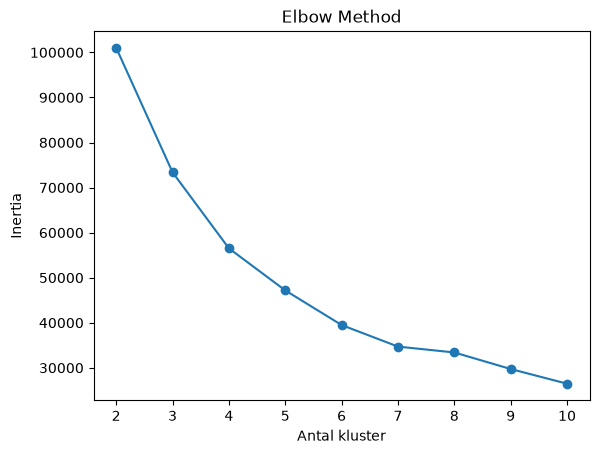

In [13]:
plt.plot(range(2, 11), inertias, marker="o")
plt.xlabel("Antal kluster")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [14]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

print(silhouette_scores)

[0.5665094919763821, 0.5134953776441145, 0.42378381535595633, 0.3772622328439901, 0.3954599683853829, 0.36290791191388344, 0.3573070924373431, 0.34188934105117796, 0.34761253198892267]


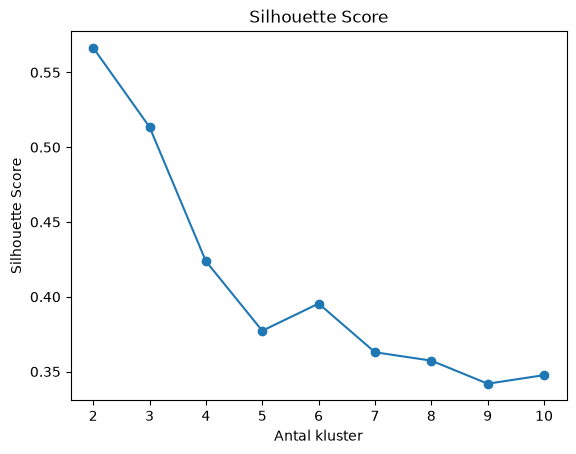

In [15]:
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.xlabel("Antal kluster")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

skapar k-means model med 6 kluster 

In [5]:
kmeans = KMeans(n_clusters=6)

tränar k-means på datan och tilldelar varje datapunkt ett kluster 

In [6]:
X["Cluster"] = kmeans.fit_predict(X)

In [7]:
X["Cluster"] = X["Cluster"].astype("category")

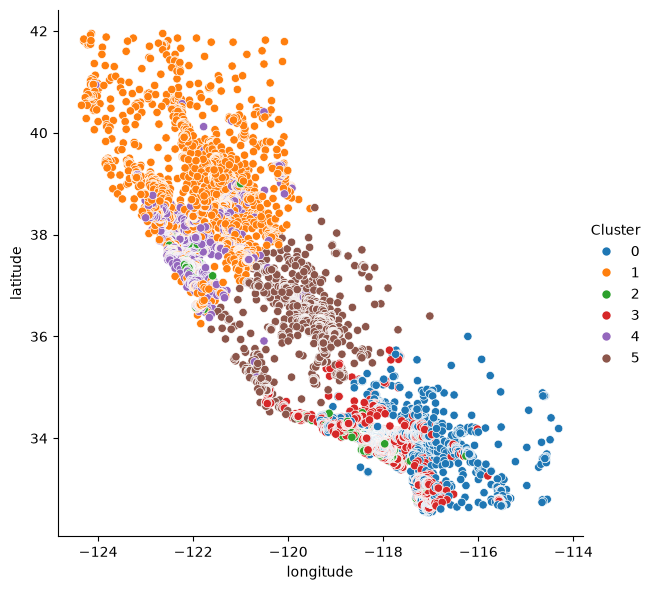

In [8]:
sns.relplot(
    x="longitude",
    y="latitude",
    hue="Cluster",
    data=X,
    height=6,
)

Koden läser in housing-datasetet och använder medianinkomst, latitud och longitud för att dela in bostäderna i sex kluster med K-means. Varje datapunkt får ett kluster från 0 till 5. Resultatet visualiseras sedan på en karta-liknande graf där färgen visar vilket kluster varje datapunkt tillhör.

B. Jag skulle undersöka demografiska egenskaper, bostadspreferenser, köpbeteende och kontaktpreferenser för varje kluster. 
Sedan skulle jag göra en enkät där personer från varje kluster får svara på frågor om exempelvis vilken typ av bostad de föredrar, prisnivå och hur de vill bli kontaktade.
 På så sätt kan man förstå vad som kännetecknar de olika klustren

D .Jag testade olika antal kluster med inertia och silhouette score. 
Elbow-metoden visade att ungefär 4–5 kluster kunde vara rimligt, medan silhouette score var högst vid 2 kluster. 
Därför bör man inte bara använda en metod utan även undersöka klustren och ta hänsyn till vad modellen ska användas till